# pix2pix Training — Real Face to Comic

This notebook trains a **pix2pix** conditional GAN to translate real face images into comic-style images.

**Architecture:**
- Generator: U-Net with skip connections
- Discriminator: 70x70 PatchGAN
- Loss: Adversarial (BCE) + L1 reconstruction
- Mixed-precision training (AMP) on CUDA for speed + lower VRAM

**Hardware:** Automatically uses CUDA (NVIDIA GPU), MPS (Apple Silicon), or CPU.


In [13]:
import os
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt


## 1. Configuration

All hyperparameters in one place. Change these to tune training.


In [14]:
# ── Hyperparameters ──
IMAGE_SIZE = 256
BATCH_SIZE = 16
NUM_EPOCHS = 100
LR = 2e-4
BETAS = (0.5, 0.999)
LAMBDA_L1 = 100
NUM_WORKERS = 4

# ── Paths (preprocessed .npy files from Notebook 2) ──
NPY_DIR = Path("../data/npy")

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_EVERY = 10

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

USE_AMP = DEVICE.type == "cuda"

print(f"Device:      {DEVICE}")
print(f"AMP:         {USE_AMP}")
print(f"Workers:     {NUM_WORKERS}")
print(f"Batch size:  {BATCH_SIZE}")
print(f"Epochs:      {NUM_EPOCHS}")


Device:      cuda
AMP:         True
Workers:     15
Batch size:  16
Epochs:      100


## 2. Load Preprocessed Data

Load the `.npy` arrays produced by **Notebook 2 (Preprocessing)**. Images are already resized to `256×256` and normalized to `[-1, 1]` in channels-first format `(N, 3, H, W)`.

In [15]:
train_real = np.load(NPY_DIR / "train_real.npy")
train_comic = np.load(NPY_DIR / "train_comic.npy")
val_real = np.load(NPY_DIR / "val_real.npy")
val_comic = np.load(NPY_DIR / "val_comic.npy")

print(f"Train — real: {train_real.shape}, comic: {train_comic.shape}")
print(f"Val   — real: {val_real.shape},   comic: {val_comic.shape}")
print(f"Pixel range:  [{train_real.min():.1f}, {train_real.max():.1f}]")

Preprocessing images to 64×64 ...
Real faces:
  Already have 10000 images in ..\data\preprocessed\real -- skipping.
Comic faces:
  Already have 10000 images in ..\data\preprocessed\comic -- skipping.

Preprocessed: 10000 real, 10000 comic images ready.


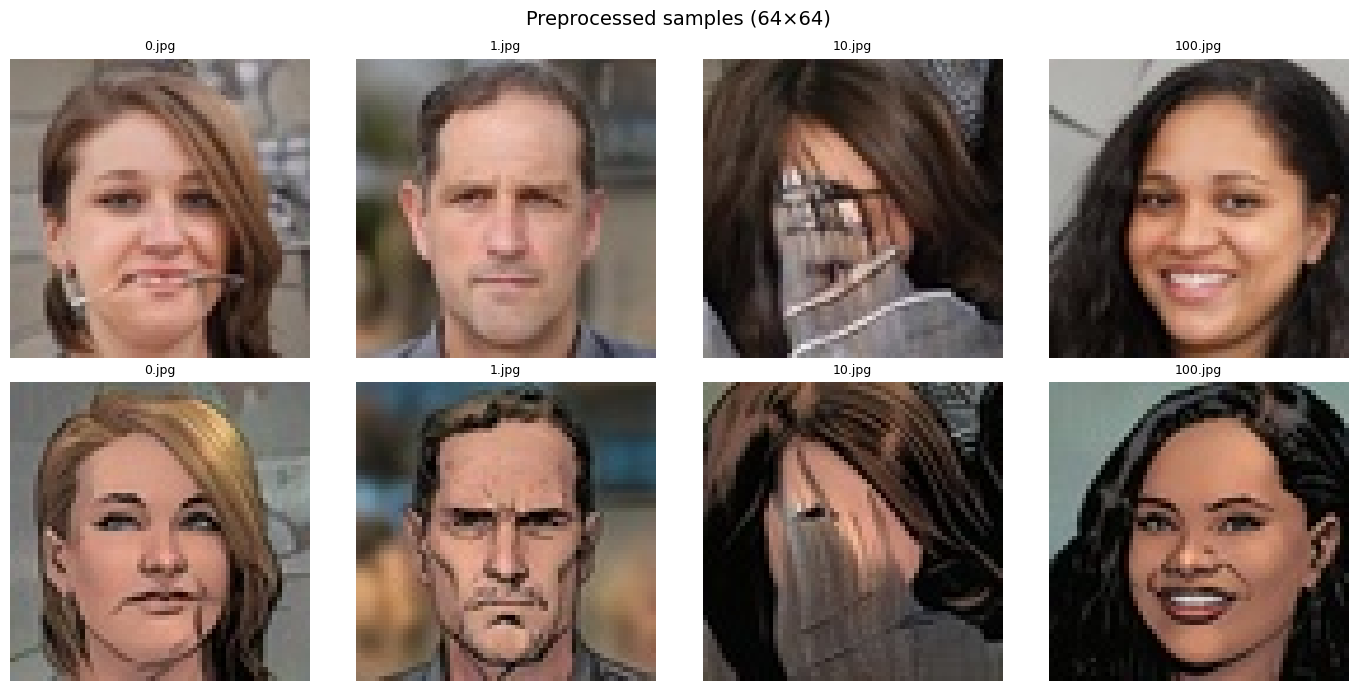

Sample real image size:  (64, 64)
Sample comic image size: (64, 64)


In [16]:
def denorm(img_chw):
    """Convert (3, H, W) float [-1,1] back to (H, W, 3) uint8 for display."""
    return ((img_chw.transpose(1, 2, 0) + 1) / 2 * 255).clip(0, 255).astype(np.uint8)


fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(denorm(train_real[i]))
    axes[0, i].set_title(f"Sample {i}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(denorm(train_comic[i]))
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Real", fontsize=12)
axes[1, 0].set_ylabel("Comic", fontsize=12)
fig.suptitle(f"Training samples ({IMAGE_SIZE}×{IMAGE_SIZE})", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Dataset & DataLoader

Wrap the NumPy arrays in a PyTorch `Dataset`. Data is already resized and normalized — the dataset just converts to tensors.


In [17]:
class FaceComicDataset(Dataset):
    """Wraps preloaded NumPy arrays as a PyTorch Dataset."""

    def __init__(self, real_array, comic_array):
        self.real = torch.from_numpy(real_array)
        self.comic = torch.from_numpy(comic_array)

    def __len__(self):
        return len(self.real)

    def __getitem__(self, idx):
        return self.real[idx], self.comic[idx]


train_dataset = FaceComicDataset(train_real, train_comic)
val_dataset = FaceComicDataset(val_real, val_comic)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Train:  {len(train_dataset):,} pairs  ({len(train_loader)} batches)")
print(f"Val:    {len(val_dataset):,} pairs  ({len(val_loader)} batches)")


Dataset size:  10,000 pairs
Batches/epoch: 625


## 4. Generator — U-Net

Encoder-decoder with skip connections. The encoder downsamples to a bottleneck, the decoder upsamples back, and skip connections carry high-frequency detail across.


In [18]:
class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetUp(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.block(x)
        return torch.cat([x, skip], dim=1)


class Generator(nn.Module):
    """U-Net generator sized for 64x64 input (6 downsample layers → 1x1 bottleneck)."""

    def __init__(self, in_ch=3, out_ch=3):
        super().__init__()
        # Encoder: 64→32→16→8→4→2→1
        self.d1 = UNetDown(in_ch, 64, normalize=False)  # 64→32
        self.d2 = UNetDown(64, 128)                      # 32→16
        self.d3 = UNetDown(128, 256)                     # 16→8
        self.d4 = UNetDown(256, 512)                     # 8→4
        self.d5 = UNetDown(512, 512)                     # 4→2
        self.d6 = UNetDown(512, 512, normalize=False)    # 2→1 (bottleneck)

        # Decoder: 1→2→4→8→16→32→64
        self.u1 = UNetUp(512, 512, dropout=True)   # 1→2,  cat d5 → 1024
        self.u2 = UNetUp(1024, 512, dropout=True)  # 2→4,  cat d4 → 1024
        self.u3 = UNetUp(1024, 256)                # 4→8,  cat d3 → 512
        self.u4 = UNetUp(512, 128)                 # 8→16, cat d2 → 256
        self.u5 = UNetUp(256, 64)                  # 16→32, cat d1 → 128

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_ch, 4, 2, 1),  # 32→64
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)

        u1 = self.u1(d6, d5)
        u2 = self.u2(u1, d4)
        u3 = self.u3(u2, d3)
        u4 = self.u4(u3, d2)
        u5 = self.u5(u4, d1)

        return self.final(u5)


## 5. Discriminator — PatchGAN

Classifies overlapping 70x70 patches as real or fake. This forces the generator to produce sharp, locally realistic textures everywhere in the image.


In [19]:
class Discriminator(nn.Module):
    def __init__(self, in_ch=6):
        super().__init__()
        def block(in_c, out_c, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_ch, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 512, 4, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 1),
        )

    def forward(self, real_input, target_or_fake):
        x = torch.cat([real_input, target_or_fake], dim=1)
        return self.model(x)


## 6. Initialize Models and Optimizers


In [20]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)
gen.apply(init_weights)
disc.apply(init_weights)

opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=BETAS)
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=BETAS)

criterion_gan = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()

gen_params = sum(p.numel() for p in gen.parameters())
disc_params = sum(p.numel() for p in disc.parameters())
print(f"Generator params:     {gen_params:,}")
print(f"Discriminator params: {disc_params:,}")


Generator params:     29,244,035
Discriminator params: 2,768,641


## 7. Training Loop

Standard pix2pix training:

1. **Discriminator step:** learn to tell real pairs from fake pairs.
2. **Generator step:** fool the discriminator + minimize L1 distance to the real comic target.

Checkpoints are saved every `SAVE_EVERY` epochs.


In [21]:
scaler_d = torch.amp.GradScaler(enabled=USE_AMP)
scaler_g = torch.amp.GradScaler(enabled=USE_AMP)

history = {"d_loss": [], "g_loss": [], "epoch_time": []}

for epoch in range(1, NUM_EPOCHS + 1):
    gen.train()
    disc.train()
    d_epoch_loss = 0.0
    g_epoch_loss = 0.0
    start = time.time()

    for real_img, comic_img in train_loader:
        real_img = real_img.to(DEVICE)
        comic_img = comic_img.to(DEVICE)

        # ── Train Discriminator ──
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            fake_comic = gen(real_img)
            disc_real = disc(real_img, comic_img)
            disc_fake = disc(real_img, fake_comic.detach())
            real_label = torch.ones_like(disc_real, device=DEVICE)
            fake_label = torch.zeros_like(disc_fake, device=DEVICE)
            loss_d_real = criterion_gan(disc_real, real_label)
            loss_d_fake = criterion_gan(disc_fake, fake_label)
            loss_d = (loss_d_real + loss_d_fake) * 0.5

        opt_disc.zero_grad()
        scaler_d.scale(loss_d).backward()
        scaler_d.step(opt_disc)
        scaler_d.update()

        # ── Train Generator ──
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            disc_fake_for_g = disc(real_img, fake_comic)
            loss_g_gan = criterion_gan(
                disc_fake_for_g,
                torch.ones_like(disc_fake_for_g, device=DEVICE),
            )
            loss_g_l1 = criterion_l1(fake_comic, comic_img) * LAMBDA_L1
            loss_g = loss_g_gan + loss_g_l1

        opt_gen.zero_grad()
        scaler_g.scale(loss_g).backward()
        scaler_g.step(opt_gen)
        scaler_g.update()

        d_epoch_loss += loss_d.item()
        g_epoch_loss += loss_g.item()

    n_batches = len(train_loader)
    d_avg = d_epoch_loss / n_batches
    g_avg = g_epoch_loss / n_batches
    elapsed = time.time() - start

    history["d_loss"].append(d_avg)
    history["g_loss"].append(g_avg)
    history["epoch_time"].append(elapsed)

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS}"
        f" | D loss: {d_avg:.4f}"
        f" | G loss: {g_avg:.4f}"
        f" | Time: {elapsed:.1f}s"
    )

    if epoch % SAVE_EVERY == 0 or epoch == NUM_EPOCHS:
        ckpt = {
            "epoch": epoch,
            "gen_state": gen.state_dict(),
            "disc_state": disc.state_dict(),
            "opt_gen_state": opt_gen.state_dict(),
            "opt_disc_state": opt_disc.state_dict(),
            "history": history,
        }
        path = CHECKPOINT_DIR / f"pix2pix_epoch_{epoch:03d}.pt"
        torch.save(ckpt, path)
        print(f"  Saved checkpoint: {path}")

print("Training complete.")


Epoch 001/100 | D loss: 0.4777 | G loss: 23.8005 | Time: 92.9s
Epoch 002/100 | D loss: 0.5020 | G loss: 22.2135 | Time: 24.0s
Epoch 003/100 | D loss: 0.5102 | G loss: 21.4803 | Time: 24.7s
Epoch 004/100 | D loss: 0.5037 | G loss: 20.8558 | Time: 24.6s
Epoch 005/100 | D loss: 0.4986 | G loss: 20.2906 | Time: 24.8s
Epoch 006/100 | D loss: 0.4994 | G loss: 19.8070 | Time: 25.2s
Epoch 007/100 | D loss: 0.5015 | G loss: 19.2366 | Time: 24.8s
Epoch 008/100 | D loss: 0.5039 | G loss: 18.7480 | Time: 25.2s
Epoch 009/100 | D loss: 0.5080 | G loss: 18.3635 | Time: 25.4s
Epoch 010/100 | D loss: 0.4995 | G loss: 18.0067 | Time: 25.2s
  Saved checkpoint: ..\checkpoints\pix2pix_epoch_010.pt
Epoch 011/100 | D loss: 0.4967 | G loss: 17.7068 | Time: 25.1s
Epoch 012/100 | D loss: 0.4896 | G loss: 17.4514 | Time: 25.1s
Epoch 013/100 | D loss: 0.4874 | G loss: 17.1706 | Time: 24.9s
Epoch 014/100 | D loss: 0.4789 | G loss: 16.9790 | Time: 26.0s
Epoch 015/100 | D loss: 0.4691 | G loss: 16.8330 | Time: 25.4s

## 8. Loss Curves


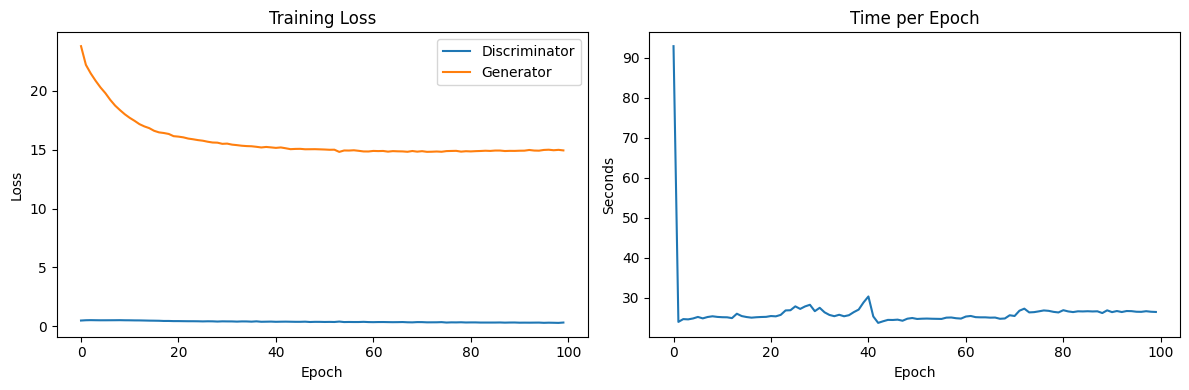

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["d_loss"], label="Discriminator")
axes[0].plot(history["g_loss"], label="Generator")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot(history["epoch_time"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Seconds")
axes[1].set_title("Time per Epoch")

plt.tight_layout()
plt.show()


## 9. Visual Results

Show a few real images alongside the generator output and the ground-truth comic target.


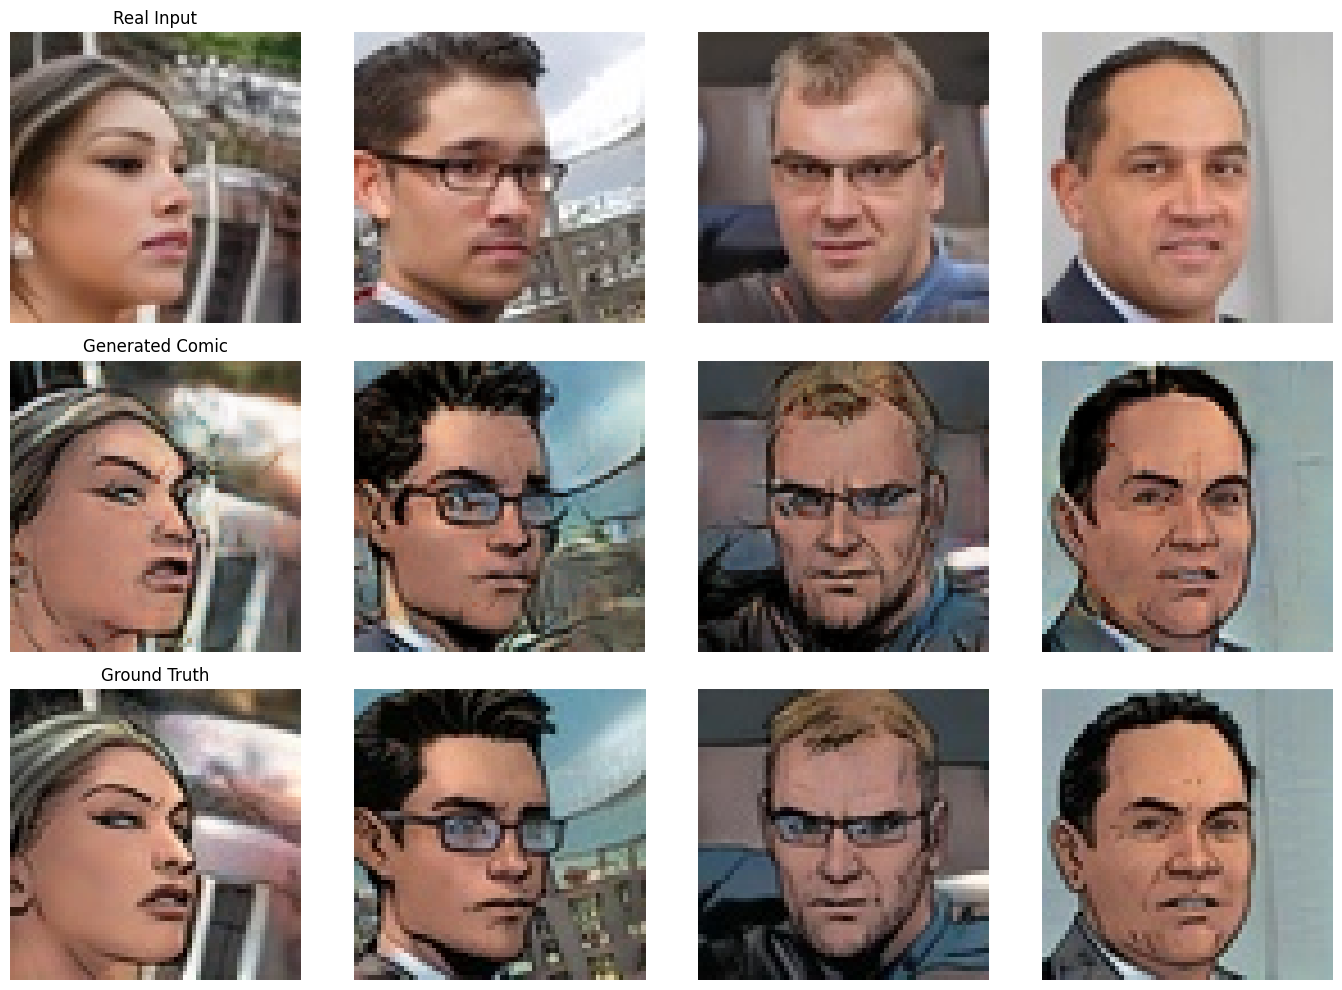

In [23]:
gen.eval()
sample_real, sample_comic = next(iter(val_loader))
sample_real = sample_real.to(DEVICE)

with torch.no_grad():
    sample_fake = gen(sample_real)


def to_numpy(tensor):
    return (tensor.cpu().numpy().transpose(0, 2, 3, 1) * 0.5 + 0.5).clip(0, 1)


real_np = to_numpy(sample_real)
comic_np = to_numpy(sample_comic)
fake_np = to_numpy(sample_fake)

n_show = min(4, len(real_np))
fig, axes = plt.subplots(3, n_show, figsize=(3.5 * n_show, 10))
row_titles = ["Real Input", "Generated Comic", "Ground Truth"]

for i in range(n_show):
    axes[0, i].imshow(real_np[i])
    axes[1, i].imshow(fake_np[i])
    axes[2, i].imshow(comic_np[i])
    for row in range(3):
        axes[row, i].axis("off")

for row, title in enumerate(row_titles):
    axes[row, 0].set_title(title, fontsize=12)

plt.tight_layout()
plt.show()
